In [58]:
# Import necessary libraries
import pytz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from scipy import stats
from sklearn.decomposition import PCA
from scipy.signal import detrend
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from astral import LocationInfo
from astral.sun import sun
from datetime import datetime, date
from jiflr import ROOT

In [ ]:
# Function to calculate lapse rate
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan

    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask]
    )

    # Convert slope to °C/100m
    lapse_rate = slope * 100

    return lapse_rate, r_value**2, p_value


def calculate_monthly_lapse_rates(df, station_filter=None):
    """
    Calculate monthly lapse rates with optional station filtering
    
    Parameters:
    -----------
    df : pandas DataFrame
        Weather data with temperature, elevation, year, month, camp_id columns
    station_filter : function, optional
        A function that takes a dataframe and returns a filtered dataframe
        e.g., lambda df: df[df['maritime']]
    
    Returns:
    --------
    pandas.DataFrame with monthly lapse rates
    """
    # Create a dataframe to store monthly lapse rates
    monthly_lapse_rates = []
    
    # Apply station filter if provided
    if station_filter is not None:
        df = station_filter(df)
    
    # Group by year, month, and sun_up status
    for (year, month, sun_up), group in df.groupby(['year', 'month', 'sun_up']):
        # Group by station and calculate average temperature
        station_temps = group.groupby(['camp_id', 'elevation'])["temperature"].mean().reset_index()
        
        # Only calculate lapse rate if we have enough stations with elevation data
        valid_stations = station_temps.dropna(subset=['elevation'])
        if len(valid_stations) >= 2:
            # Calculate lapse rate
            lr, r2, p = calculate_lapse_rate(
                valid_stations["temperature"].values,
                valid_stations['elevation'].values
            )
            
            # Store results
            monthly_lapse_rates.append({
                'year': year,
                'month': month,
                'sun_up': sun_up,
                'lapse_rate': lr,
                'r2': r2,
                'p_value': p,
                'stations_used': len(valid_stations)
            })
    
    # Create dataframe and add date column
    result_df = pd.DataFrame(monthly_lapse_rates)
    if not result_df.empty:
        result_df['date'] = pd.to_datetime(result_df[['year', 'month']].assign(day=1))
        
        # Add season column
        result_df['season'] = result_df['date'].apply(get_season)
    
    return result_df


def calculate_sunrise_sunset(latitude, longitude, dates, timezone="America/Anchorage"):
    """
    Calculate sunrise and sunset times for a specific location across multiple dates.

    Parameters:
    latitude (float): Latitude of the location
    longitude (float): Longitude of the location
    dates (iterable): Iterable of dates (datetime, date objects, or pandas Timestamps)
    timezone (str): Timezone string (default: "America/Anchorage")

    Returns:
    tuple: (sunrise_times, sunset_times) - Two arrays of datetime objects
    """
    # Create location
    location = LocationInfo(latitude=latitude, longitude=longitude, timezone=timezone)
    tz = pytz.timezone(timezone)

    # Initialize lists for results
    sunrise_times = []
    sunset_times = []

    # Extract unique dates (in case there are duplicates in the input)
    unique_dates = set()
    for d in dates:
        # Handle different date formats
        if isinstance(d, (pd.Timestamp, datetime)):
            unique_dates.add(d.date())
        elif isinstance(d, date):
            unique_dates.add(d)
        else:
            try:
                # Try to parse string dates
                parsed_date = pd.to_datetime(d).date()
                unique_dates.add(parsed_date)
            except:
                raise ValueError(f"Unrecognized date format: {d}")

    # Sort dates for consistent ordering
    unique_dates = sorted(unique_dates)

    # Calculate sunrise and sunset for each date
    for current_date in unique_dates:
        try:
            s = sun(location.observer, date=current_date, tzinfo=tz)
            sunrise_times.append(s["sunrise"])
            sunset_times.append(s["sunset"])
        except Exception as e:
            # Handle edge cases (e.g., polar day/night)
            print(
                f"Warning: Could not calculate sun times for {current_date} at {latitude},{longitude}: {e}"
            )
            sunrise_times.append(None)
            sunset_times.append(None)

    return sunrise_times, sunset_times

In [3]:
# Read the station locations
wx_stations = pd.read_csv(
    Path(
        ROOT,
        "data/external/JIRP_AWS_Stations/juneauIceField_weather_v1.0/WeatherStationLocations.csv",
    )
)
wx_stations

,Location,Elevation,Latitude,Longitude,NWIS ID
0,C-10,1196,59.575640,-133.709820,NaN
1,C-17,1285,58.647210,-134.206350,NaN
2,C-26,1435,58.367370,-134.366380,NaN
3,C-9,1555,59.016640,-134.121040,NaN
4,C-29,1618,58.712433,-134.182217,NaN
5,C-18,1705,59.342110,-134.102210,NaN
6,C-8,2050,58.834970,-134.276430,NaN
7,C-25,2121,58.806700,-134.136130,NaN


In [18]:
# Load the McGee JIRP hourly data
mcgee_data_path = Path(
    ROOT,
    "notebooks/camp-wx-lapse-rate/processed_data/mcgee_jirp_hourly_weather_data.csv",
)
df_mcgee = pd.read_csv(mcgee_data_path)

# Convert to datetime and sort
df_mcgee["datetime"] = pd.to_datetime(df_mcgee["datetime"], format="mixed").dt.round(
    "s"
)
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])

# Approach: Handle the DST transitions manually, not relying on automatic handling

# 1. Make a copy of the original naive datetimes for reference
df_mcgee["naive_dt"] = df_mcgee["datetime"].copy()


# 2. Use a function to manually handle each timestamp
def localize_with_dst_handling(dt, is_dup):
    ak_tz = pytz.timezone("America/Anchorage")

    try:
        # For spring transition (nonexistent times)
        return dt.tz_localize(ak_tz, nonexistent="shift_backward")
    except pytz.exceptions.AmbiguousTimeError:
        # For fall transition (ambiguous times)
        # First occurrence is DST, second is standard time
        return dt.tz_localize(ak_tz, ambiguous=not is_dup)
    except Exception as e:
        print(f"Error with {dt}: {e}")
        return pd.NaT


# 3. Apply the function row by row
# First, identify duplicates for the fall transition
df_mcgee["is_duplicate"] = df_mcgee.duplicated(["datetime", "camp_id"], keep="first")

# Apply localization with proper handling
result = []
for idx, row in df_mcgee.iterrows():
    localized_dt = localize_with_dst_handling(row["datetime"], row["is_duplicate"])
    result.append(localized_dt)

df_mcgee["datetime"] = result

# 4. Clean up and sort
df_mcgee["date"] = df_mcgee["datetime"].dt.date
df_mcgee = df_mcgee.drop(["is_duplicate"], axis=1)
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])
df_mcgee

,datetime,camp_id,temperature,elevation,latitude,longitude,nwis_id,date,naive_dt
367,1998-08-02 07:00:00-08:00,C-10,46.820,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 07:00:00
373,1998-08-02 10:00:00-08:00,C-10,62.170,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 10:00:00
378,1998-08-02 13:00:00-08:00,C-10,55.280,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 13:00:00
384,1998-08-02 16:00:00-08:00,C-10,59.420,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 16:00:00
390,1998-08-02 19:00:00-08:00,C-10,59.420,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 19:00:00
...,...,...,...,...,...,...,...,...,...
1285861,2024-07-24 07:00:00-08:00,C-8,45.172,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 07:00:00
1285866,2024-07-24 08:00:00-08:00,C-8,45.444,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 08:00:00
1285871,2024-07-24 09:00:00-08:00,C-8,45.624,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 09:00:00
1285876,2024-07-24 10:00:00-08:00,C-8,46.841,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 10:00:00


In [19]:
# ======================
# VERIFICATION CHECKS
# ======================

# 1. Check for duplicates in processed data
duplicate_check = df_mcgee.duplicated(["datetime", "camp_id"], keep=False)
if duplicate_check.any():
    print("WARNING: Duplicates found after processing!")
    print(f"Number of duplicates: {duplicate_check.sum()}")
    duplicates = df_mcgee[duplicate_check].sort_values(["camp_id", "datetime"])
    print(duplicates[["camp_id", "datetime", "naive_dt"]].head(10))
else:
    print("SUCCESS: No duplicates found after processing.")

# 2. Check for NaT values
nat_check = df_mcgee["datetime"].isna()
if nat_check.any():
    print(f"WARNING: {nat_check.sum()} NaT values found!")
    print(df_mcgee[nat_check][["camp_id", "naive_dt"]].head())
else:
    print("SUCCESS: No NaT values found.")

# 3. Check for time gaps
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])
df_mcgee["time_diff"] = df_mcgee.groupby("camp_id")["datetime"].diff()

# Expected gaps: Mostly 1 hour, some 2 hours for spring transition
one_hour = pd.Timedelta(hours=1)
two_hours = pd.Timedelta(hours=2)

unexpected_gaps = ~(
    (df_mcgee["time_diff"].isna())  # First entry in each group
    | (df_mcgee["time_diff"] == one_hour)  # Normal 1-hour gap
    | (df_mcgee["time_diff"] == two_hours)  # Spring transition 2-hour gap
)

if unexpected_gaps.any():
    print(f"WARNING: {unexpected_gaps.sum()} unexpected time gaps found!")
    print(
        df_mcgee[unexpected_gaps][
            ["camp_id", "datetime", "naive_dt", "time_diff"]
        ].head(10)
    )
else:
    print(
        "SUCCESS: All time gaps are as expected (1 hour or 2 hours for spring transition)."
    )

# Clean up temporary columns
df_mcgee = df_mcgee.drop(["naive_dt", "time_diff"], axis=1)

SUCCESS: No duplicates found after processing.
SUCCESS: No NaT values found.
    camp_id                  datetime            naive_dt       time_diff
373    C-10 1998-08-02 10:00:00-08:00 1998-08-02 10:00:00 0 days 03:00:00
378    C-10 1998-08-02 13:00:00-08:00 1998-08-02 13:00:00 0 days 03:00:00
384    C-10 1998-08-02 16:00:00-08:00 1998-08-02 16:00:00 0 days 03:00:00
390    C-10 1998-08-02 19:00:00-08:00 1998-08-02 19:00:00 0 days 03:00:00
396    C-10 1998-08-02 22:00:00-08:00 1998-08-02 22:00:00 0 days 03:00:00
402    C-10 1998-08-03 01:00:00-08:00 1998-08-03 01:00:00 0 days 03:00:00
408    C-10 1998-08-03 04:00:00-08:00 1998-08-03 04:00:00 0 days 03:00:00
414    C-10 1998-08-03 07:00:00-08:00 1998-08-03 07:00:00 0 days 03:00:00
420    C-10 1998-08-03 10:00:00-08:00 1998-08-03 10:00:00 0 days 03:00:00
426    C-10 1998-08-03 13:00:00-08:00 1998-08-03 13:00:00 0 days 03:00:00


In [ ]:
# Extract time components
df_mcgee["month"] = df_mcgee["datetime"].dt.month
df_mcgee["hour"] = df_mcgee["datetime"].dt.hour
df_mcgee["year"] = df_mcgee["datetime"].dt.year
df_mcgee["day"] = df_mcgee["datetime"].dt.day
df_mcgee["season"] = pd.cut(
    df_mcgee["month"],
    bins=[0, 3, 6, 9, 12],
    labels=["Winter", "Spring", "Summer", "Fall"],
)

# Filter for summer months (June, July, August)
df_mcgee_summer = df_mcgee[(df_mcgee["month"] >= 6) & (df_mcgee["month"] <= 8)]


# Define the transect order from maritime to continental
transect_order = ["C-17", "C-10", "C-9", "C-18", "C-8", "C-25", "C-26", "C-29", "C-30"]

# Create a numeric index for the position in the transect
transect_position = {camp: i for i, camp in enumerate(transect_order)}

# Add transect position to the dataframes
df_mcgee["transect_pos"] = df_mcgee["camp_id"].map(transect_position)
df_mcgee_summer["transect_pos"] = df_mcgee_summer["camp_id"].map(transect_position)

# Split stations into maritime and continental segments
maritime_stations = ["C-17", "C-10", "C-9", "C-18", "C-8"]
continental_stations = ["C-8", "C-25", "C-26", "C-29", "C-30"]
icefield_stations = ["C-17", "C-10", "C-9", "C-18","C-8", "C-25", "C-26"]

# Add maritime column (True for camp_id in [17, 10, 9, 18, 8])
df_mcgee['maritime'] = df_mcgee['camp_id'].isin(maritime_stations)

# Add continental column (True for camp_id in [18, 8, 25, 26, 29, 30])
df_mcgee['continental'] = df_mcgee['camp_id'].isin(continental_stations)

# Add on_icefield column (True for all camp_id except 29 and 30)
df_mcgee['on_icefield'] = df_mcgee['camp_id'].isin(icefield_stations)

# Verify the new columns
print(f"Maritime stations: {df_mcgee['maritime'].sum()} rows")
print(f"Continental stations: {df_mcgee['continental'].sum()} rows")
print(f"On icefield stations: {df_mcgee['on_icefield'].sum()} rows")

# Show the distribution by camp_id
summary = df_mcgee.groupby('camp_id').first()[['maritime', 'continental', 'on_icefield']]
print("\nStation classifications:")
print(summary)

# Display basic information about the dataset
print(f"Total records: {len(df_mcgee)}")
print(f"Summer records: {len(df_mcgee_summer)}")
print(f"Date range: {df_mcgee['datetime'].min()} to {df_mcgee['datetime'].max()}")
print(f"Unique stations: {df_mcgee['camp_id'].nunique()}")
print(f"Stations: {sorted(df_mcgee['camp_id'].unique())}")

# Check if we have elevation data for all stations
elevation_summary = df_mcgee.groupby("camp_id")["elevation"].first().reset_index()
print("\nElevation data by station:")
print(elevation_summary)

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_89707/4070967694.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mcgee_summer["transect_pos"] = df_mcgee_summer["camp_id"].map(transect_position)


Maritime stations: 735790 rows
Continental stations: 747585 rows
On icefield stations: 1115075 rows

Station classifications:
         maritime  continental  on_icefield
camp_id                                    
C-10         True        False         True
C-17         True        False         True
C-18         True        False         True
C-25        False         True         True
C-26        False         True         True
C-30        False         True        False
C-8          True         True         True
Total records: 1286726
Summer records: 318436
Date range: 1998-07-20 10:00:00-08:00 to 2024-08-09 15:00:00-08:00
Unique stations: 7
Stations: ['C-10', 'C-17', 'C-18', 'C-25', 'C-26', 'C-30', 'C-8']

Elevation data by station:
  camp_id  elevation
0    C-10       1196
1    C-17       1285
2    C-18       1705
3    C-25       2121
4    C-26       1435
5    C-30        674
6     C-8       2050


In [37]:
# Process each station
for _, station in wx_stations.iterrows():
    station_name = station["Location"]
    lat = float(station["Latitude"])
    lon = float(station["Longitude"])

    # Get data for this station
    station_data = df_mcgee[df_mcgee["camp_id"] == station_name]
    if station_data.empty:
        continue

    # Get unique dates for this station
    dates = station_data["datetime"].unique()

    # Calculate sunrise and sunset times
    sunrise_times, sunset_times = calculate_sunrise_sunset(lat, lon, dates)

    # Create a mapping of date to sunrise/sunset
    sun_dict = {}
    for d, rise, set_ in zip(
        sorted(set(d.date() for d in dates)), sunrise_times, sunset_times
    ):
        sun_dict[d] = (rise, set_)

    # Update the sun_status for each timestamp
    for idx in station_data.index:
        timestamp = df_mcgee.loc[idx, "datetime"]
        day = df_mcgee.loc[idx, "date"]

        if day in sun_dict:
            sunrise, sunset = sun_dict[day]
            if sunrise and sunset and sunrise <= timestamp <= sunset:
                df_mcgee.loc[idx, "sun_up"] = True

# fill the other times with False
df_mcgee["sun_up"] = df_mcgee["sun_up"].fillna(False)

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_89707/3262265779.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mcgee["sun_up"] = df_mcgee["sun_up"].fillna(False)


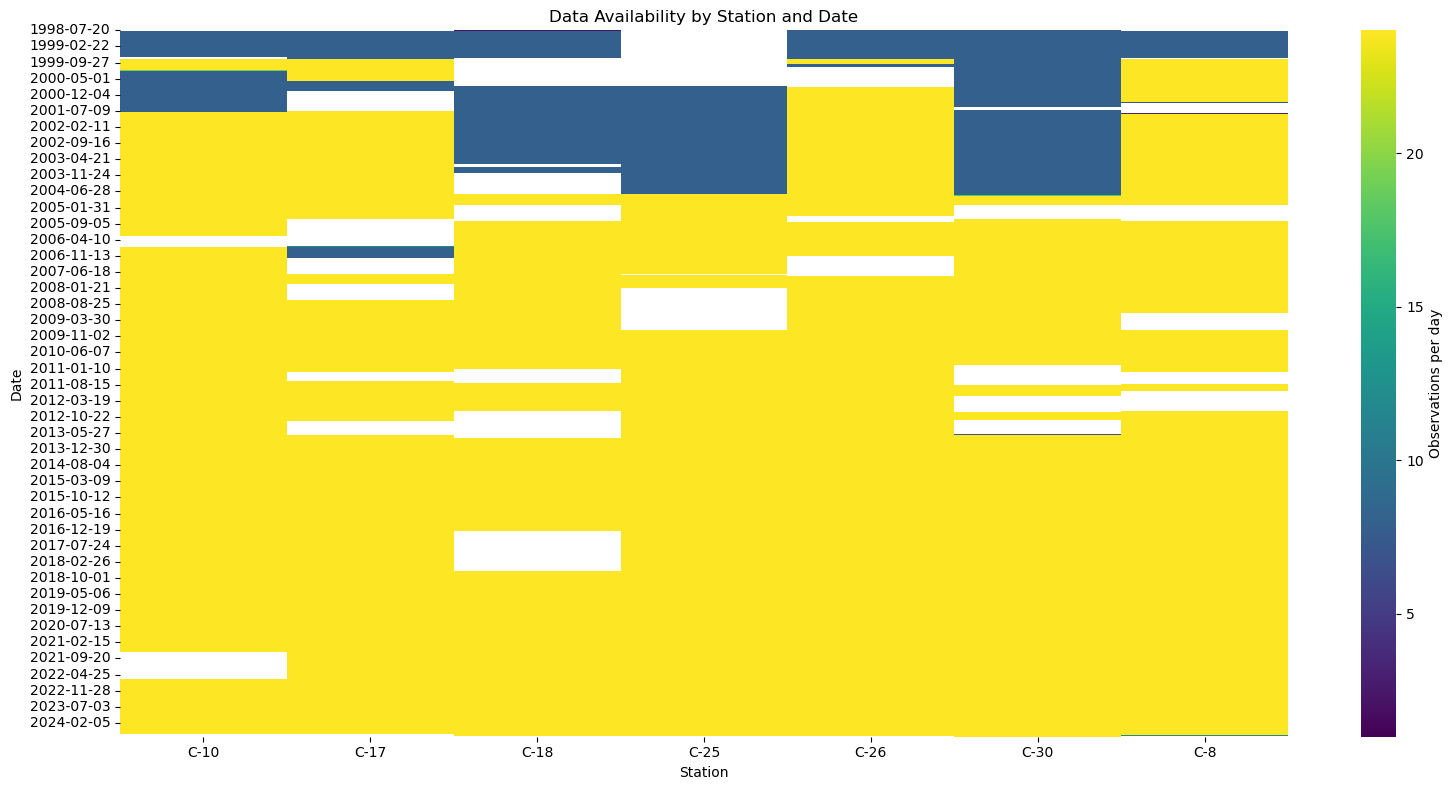

In [25]:
# --------------------------
# 1. Data Availability and Completeness
# --------------------------
# Visualize data availability by station and date
plt.figure(figsize=(16, 8))

# Count observations by station and date
availability = df_mcgee.groupby(["date", "camp_id"]).size().reset_index(name="count")

# Create a pivot table
pivot_avail = availability.pivot(index="date", columns="camp_id", values="count")

# Plot availability heatmap
sns.heatmap(pivot_avail, cmap="viridis", cbar_kws={"label": "Observations per day"})
plt.title("Data Availability by Station and Date")
plt.ylabel("Date")
plt.xlabel("Station")
plt.tight_layout()
plt.show()

In [ ]:



    
    
def plot_lapse_rates(df, title_prefix="", figsize=(14, 7)):
    """
    Plot lapse rate data.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Must contain 'date', 'lapse_rate', 'r2', and 'stations_used' columns.
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    # Single panel plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use fixed bubble size
    scatter = ax.scatter(df['date'], df['lapse_rate'],
                       c=df['r2'], cmap='viridis',
                       alpha=0.8, edgecolor='k', s=50)
    
    ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
             label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title(f'{title_prefix} (n={len(df)})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.xticks(rotation=45)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('R² value')
    
    plt.tight_layout()
    return fig

In [ ]:
# 2. Define filters for different station groups
filters = {
    'all': lambda df: df,
    'maritime': lambda df: df[df['maritime']],
    'continental': lambda df: df[df['continental']],
    'continental_on_icefield': lambda df: df[df['continental'] & df['on_icefield']]
}

# 3. Calculate lapse rates for each group
lapse_rate_dfs = {}
for group_name, filter_func in filters.items():
    lapse_rate_dfs[group_name] = calculate_monthly_lapse_rates(df_mcgee, filter_func)

# 4. Generate plots
plot_configs = [
    # All stations
    ('all', None, None, 'All Stations - All Year'),
    ('all', None, True, 'All Stations - All Year - Daytime'),
    ('all', None, False, 'All Stations - All Year - Nighttime'),
    
    # Maritime stations
    ('maritime', None, None, 'Maritime Stations - All Year'),
    ('maritime', None, True, 'Maritime Stations - All Year - Daytime'),
    ('maritime', None, False, 'Maritime Stations - All Year - Nighttime'),
    ('maritime', 'Spring', None, 'Maritime Stations - Spring'),
    ('maritime', 'Summer', None, 'Maritime Stations - Summer'),
    ('maritime', 'Summer', True, 'Maritime Stations - Summer - Daytime'),
    ('maritime', 'Summer', False, 'Maritime Stations - Summer - Nighttime'),
    ('maritime', 'Fall', None, 'Maritime Stations - Fall'),
    ('maritime', 'Winter', None, 'Maritime Stations - Winter'),
    
    # Continental stations
    ('continental', None, None, 'Continental Stations - All Year'),
    ('continental', None, True, 'Continental Stations - All Year - Daytime'),
    ('continental', None, False, 'Continental Stations - All Year - Nighttime'),
    ('continental', 'Spring', None, 'Continental Stations - Spring'),
    ('continental', 'Summer', None, 'Continental Stations - Summer'),
    ('continental', 'Summer', True, 'Continental Stations - Summer - Daytime'),
    ('continental', 'Summer', False, 'Continental Stations - Summer - Nighttime'),
    ('continental', 'Fall', None, 'Continental Stations - Fall'),
    ('continental', 'Winter', None, 'Continental Stations - Winter'),
    
    # Continental on-icefield stations
    ('continental_on_icefield', None, None, 'Continental On-Icefield Stations - All Year'),
    ('continental_on_icefield', None, True, 'Continental On-Icefield Stations - All Year - Daytime'),
    ('continental_on_icefield', None, False, 'Continental On-Icefield Stations - All Year - Nighttime'),
    ('continental_on_icefield', 'Spring', None, 'Continental On-Icefield - Spring'),
    ('continental_on_icefield', 'Summer', None, 'Continental On-Icefield - Summer'),
    ('continental_on_icefield', 'Summer', True, 'Continental On-Icefield - Summer - Daytime'),
    ('continental_on_icefield', 'Summer', False, 'Continental On-Icefield - Summer - Nighttime'),
    ('continental_on_icefield', 'Fall', None, 'Continental On-Icefield - Fall'),
    ('continental_on_icefield', 'Winter', None, 'Continental On-Icefield - Winter')
]

for group, season, day_night, title in plot_configs:
    # Get the base dataframe for this group
    df = lapse_rate_dfs[group]
    if df.empty:
        print(f"No data for {title}")
        continue
    
    # Apply season filter if specified
    if season is not None:
        df = df[df['season'] == season]
    
    # Apply day/night filter if specified
    if day_night is not None:
        df = df[df['sun_up'] == day_night]
    
    # Skip if no data after filtering
    if len(df) == 0:
        print(f"No data for {title}")
        continue
    
    # Generate plot
    fig = plot_lapse_rates(df, title_prefix=title)
    
    # Convert title to filename
    filename = title.lower().replace(' ', '_').replace('-', '_')
    fig.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Generated plot: {title}")

Generated plot: All Stations - All Year
Generated plot: All Stations - All Year - Daytime
Generated plot: All Stations - All Year - Nighttime
Generated plot: Maritime Stations - All Year
Generated plot: Maritime Stations - All Year - Daytime
Generated plot: Maritime Stations - All Year - Nighttime
Generated plot: Maritime Stations - Spring
Generated plot: Maritime Stations - Summer
Generated plot: Maritime Stations - Summer - Daytime
Generated plot: Maritime Stations - Summer - Nighttime
Generated plot: Maritime Stations - Fall
Generated plot: Maritime Stations - Winter
Generated plot: Continental Stations - All Year
Generated plot: Continental Stations - All Year - Daytime
Generated plot: Continental Stations - All Year - Nighttime
Generated plot: Continental Stations - Spring
Generated plot: Continental Stations - Summer
Generated plot: Continental Stations - Summer - Daytime
Generated plot: Continental Stations - Summer - Nighttime
Generated plot: Continental Stations - Fall
Generat

In [ ]:
def calculate_temporal_lapse_rates(df, period='monthly', station_filter=None):
    """
    Calculate lapse rates with temporal aggregation and optional station filtering
    
    Parameters:
    -----------
    df : pandas DataFrame
        Weather data with temperature, elevation, year, month, camp_id columns
    period : str
        Aggregation period: 'daily' or 'monthly'
    station_filter : function, optional
        A function that takes a dataframe and returns a filtered dataframe
        e.g., lambda df: df[df['maritime']]
    
    Returns:
    --------
    pandas.DataFrame with lapse rates
    """
    # Create a dataframe to store lapse rates
    lapse_rates = []
    
    # Apply station filter if provided
    if station_filter is not None:
        df = station_filter(df)
    
    # Group by appropriate time period and sun_up status
    if period == 'daily':
        # Use year, month, day for daily calculations
        groupby_cols = ['year', 'month', 'day', 'sun_up']
    else:  # monthly
        # Use year, month for monthly calculations
        groupby_cols = ['year', 'month', 'sun_up']
    
    for group_key, group in df.groupby(groupby_cols):
        # Extract group information
        if period == 'daily':
            year, month, day, sun_up = group_key
        else:  # monthly
            year, month, sun_up = group_key
            day = 1  # Default day for monthly aggregation
        
        # Group by station and calculate average temperature
        station_temps = group.groupby(['camp_id', 'elevation'])["temperature"].mean().reset_index()
        
        # Only calculate lapse rate if we have enough stations with elevation data
        valid_stations = station_temps.dropna(subset=['elevation'])
        if len(valid_stations) >= 2:
            # Calculate lapse rate
            lr, r2, p = calculate_lapse_rate(
                valid_stations["temperature"].values,
                valid_stations['elevation'].values
            )
            
            # Store results
            result = {
                'year': year,
                'month': month,
                'sun_up': sun_up,
                'lapse_rate': lr,
                'r2': r2,
                'p_value': p,
                'stations_used': len(valid_stations)
            }
            
            # Add day for daily calculations
            if period == 'daily':
                result['day'] = day
                
            lapse_rates.append(result)
    
    # Create dataframe and add date column
    result_df = pd.DataFrame(lapse_rates)
    if not result_df.empty:
        if period == 'daily':
            result_df['date'] = pd.to_datetime(result_df[['year', 'month', 'day']])
        else:  # monthly
            result_df['date'] = pd.to_datetime(result_df[['year', 'month']].assign(day=1))
        
        # Add season column
        result_df['season'] = result_df['date'].apply(get_season)
    
    return result_df


def plot_lapse_rates(df, title_prefix="", figsize=(14, 7)):
    """
    Plot lapse rate data.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Must contain 'date', 'lapse_rate', 'r2', and 'stations_used' columns.
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    # Single panel plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use fixed bubble size
    scatter = ax.scatter(df['date'], df['lapse_rate'],
                       c=df['r2'], cmap='viridis',
                       alpha=0.8, edgecolor='k', s=50)
    
    ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
             label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title(f'{title_prefix} (n={len(df)})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.xticks(rotation=45)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('R² value')
    
    plt.tight_layout()
    return fig


def plot_day_night_lapse_rates(day_df, night_df, title_prefix="", figsize=(14, 7)):
    """
    Plot daytime and nighttime lapse rates on the same plot with different color schemes.
    
    Parameters:
    -----------
    day_df : pandas DataFrame
        Daytime lapse rate data with 'date', 'lapse_rate', 'r2' columns
    night_df : pandas DataFrame
        Nighttime lapse rate data with 'date', 'lapse_rate', 'r2' columns
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create discrete color levels for R² values (0.1 to 1.0)
    levels = np.linspace(0.1, 1.0, 10)
    
    # Normalize R² values to the discrete levels
    day_r2_discrete = np.digitize(day_df['r2'], levels) / 10
    night_r2_discrete = np.digitize(night_df['r2'], levels) / 10
    
    # Create custom colormaps with discrete colors
    # YlOrRd for day (yellow to red, like sunlight)
    # Blues for night
    day_cmap = plt.cm.YlOrRd
    night_cmap = plt.cm.Blues
    
    # Create discrete colormap for day
    day_colors = day_cmap(np.linspace(0.2, 1, 10))  # Start at 0.2 to avoid too pale colors
    day_cmap_discrete = mcolors.ListedColormap(day_colors)
    
    # Create discrete colormap for night
    night_colors = night_cmap(np.linspace(0.2, 1, 10))  # Start at 0.2 to avoid too pale colors
    night_cmap_discrete = mcolors.ListedColormap(night_colors)
    
    # Plot daytime data
    scatter_day = ax.scatter(day_df['date'], day_df['lapse_rate'],
                          c=day_df['r2'], cmap=day_cmap_discrete,
                          vmin=0, vmax=1,
                          alpha=0.8, edgecolor='k', s=50, marker='o',
                          label='Day')
    
    # Plot nighttime data
    scatter_night = ax.scatter(night_df['date'], night_df['lapse_rate'],
                            c=night_df['r2'], cmap=night_cmap_discrete,
                            vmin=0, vmax=1,
                            alpha=0.8, edgecolor='k', s=50, marker='s',  # Square marker to differentiate
                            label='Night')
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
             label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title(f'{title_prefix} (Day n={len(day_df)}, Night n={len(night_df)})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Adjust interval as needed
    plt.xticks(rotation=45)
    
    # Add colorbars
    # Position for day colorbar - left side
    cax_day = fig.add_axes([0.125, 0.11, 0.35, 0.03])  # [left, bottom, width, height]
    
    # Position for night colorbar - right side
    cax_night = fig.add_axes([0.55, 0.11, 0.35, 0.03])  # [left, bottom, width, height]
    
    # Create discrete norm for colorbars
    bounds = np.linspace(0, 1, 11)  # 11 bounds for 10 levels
    norm = mcolors.BoundaryNorm(bounds, 10)
    
    # Add day colorbar
    cbar_day = fig.colorbar(ScalarMappable(norm=norm, cmap=day_cmap_discrete), 
                          cax=cax_day, orientation='horizontal', ticks=bounds[:-1] + 0.05)
    cbar_day.set_label('Day R² value', labelpad=0.5)
    
    # Add night colorbar
    cbar_night = fig.colorbar(ScalarMappable(norm=norm, cmap=night_cmap_discrete), 
                            cax=cax_night, orientation='horizontal', ticks=bounds[:-1] + 0.05)
    cbar_night.set_label('Night R² value', labelpad=0.5)
    
    plt.subplots_adjust(bottom=0.22)  # Make room for colorbars
    return fig

In [ ]:
# 2. Define filters for different station groups
filters = {
    'all': lambda df: df,
    'maritime': lambda df: df[df['maritime']],
    'continental': lambda df: df[df['continental']],
    'continental_on_icefield': lambda df: df[df['continental'] & df['on_icefield']]
}

# 3. Calculate monthly lapse rates for each group
monthly_lapse_rate_dfs = {}
for group_name, filter_func in filters.items():
    monthly_lapse_rate_dfs[group_name] = calculate_temporal_lapse_rates(df_mcgee, 'monthly', filter_func)

# 4. Calculate daily lapse rates for each group
daily_lapse_rate_dfs = {}
for group_name, filter_func in filters.items():
    daily_lapse_rate_dfs[group_name] = calculate_temporal_lapse_rates(df_mcgee, 'daily', filter_func)

# 5. Generate combined day/night plots for monthly data
day_night_plot_configs = [
    # (group, season, title)
    ('all', None, 'All Stations - Day vs Night - All Year'),
    ('maritime', None, 'Maritime Stations - Day vs Night - All Year'),
    ('continental', None, 'Continental Stations - Day vs Night - All Year'),
    ('continental_on_icefield', None, 'Continental On-Icefield - Day vs Night - All Year'),
    
    # Season-specific plots
    ('all', 'Summer', 'All Stations - Day vs Night - Summer'),
    ('maritime', 'Summer', 'Maritime Stations - Day vs Night - Summer'),
    ('continental', 'Summer', 'Continental Stations - Day vs Night - Summer'),
    ('continental_on_icefield', 'Summer', 'Continental On-Icefield - Day vs Night - Summer')
]

for group, season, title in day_night_plot_configs:
    # Get the base dataframe for this group
    df = monthly_lapse_rate_dfs[group]
    if df.empty:
        print(f"No data for {title}")
        continue
    
    # Apply season filter if specified
    if season is not None:
        df = df[df['season'] == season]
    
    # Split into day and night
    day_df = df[df['sun_up']]
    night_df = df[~df['sun_up']]
    
    # Skip if either day or night has no data
    if len(day_df) == 0 or len(night_df) == 0:
        print(f"No day or night data for {title}")
        continue
    
    # Generate plot
    fig = plot_day_night_lapse_rates(day_df, night_df, title_prefix=title)
    
    # Convert title to filename
    filename = title.lower().replace(' ', '_').replace('-', '_')
    fig.savefig(f"{filename}_monthly.png", dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Generated monthly plot: {title}")

# 6. Generate combined day/night plots for daily data
for group, season, title in day_night_plot_configs:
    # Get the base dataframe for this group
    df = daily_lapse_rate_dfs[group]
    if df.empty:
        print(f"No daily data for {title}")
        continue
    
    # Apply season filter if specified
    if season is not None:
        df = df[df['season'] == season]
    
    # Split into day and night
    day_df = df[df['sun_up']]
    night_df = df[~df['sun_up']]
    
    # Skip if either day or night has no data
    if len(day_df) == 0 or len(night_df) == 0:
        print(f"No daily day or night data for {title}")
        continue
    
    # Generate plot
    fig = plot_day_night_lapse_rates(day_df, night_df, title_prefix=f"{title} (Daily)")
    
    # Convert title to filename
    filename = title.lower().replace(' ', '_').replace('-', '_')
    fig.savefig(f"{filename}_daily.png", dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Generated daily plot: {title}")

Generated monthly plot: All Stations - Day vs Night - All Year
Generated monthly plot: Maritime Stations - Day vs Night - All Year
Generated monthly plot: Continental Stations - Day vs Night - All Year
Generated monthly plot: Continental On-Icefield - Day vs Night - All Year
Generated monthly plot: All Stations - Day vs Night - Summer
Generated monthly plot: Maritime Stations - Day vs Night - Summer
Generated monthly plot: Continental Stations - Day vs Night - Summer
Generated monthly plot: Continental On-Icefield - Day vs Night - Summer
Generated daily plot: All Stations - Day vs Night - All Year
Generated daily plot: Maritime Stations - Day vs Night - All Year
Generated daily plot: Continental Stations - Day vs Night - All Year
Generated daily plot: Continental On-Icefield - Day vs Night - All Year
Generated daily plot: All Stations - Day vs Night - Summer
Generated daily plot: Maritime Stations - Day vs Night - Summer
Generated daily plot: Continental Stations - Day vs Night - Summe

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import matplotlib.lines as mlines
import seaborn as sns

# Utility function for standard formatting
def apply_standard_formatting(ax):
    """Apply standardized formatting to any plot axis"""
    # Set standard y-axis limits
    ax.set_ylim(-2.5, 1.0)
    # Add gridlines
    ax.grid(True, alpha=0.3)
    return ax

# Modified main plotting functions with standardized formatting

def plot_lapse_rates(df, title_prefix="", figsize=(14, 7)):
    """
    Plot lapse rate data.

    Parameters:
    -----------
    df : pandas DataFrame
        Must contain 'date', 'lapse_rate', 'r2', and 'stations_used' columns.
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)

    Returns:
    --------
    fig : matplotlib figure object
    """
    # Single panel plot
    fig, ax = plt.subplots(figsize=figsize)

    # Use fixed marker size and consistent marker shape
    scatter = ax.scatter(
        df["date"],
        df["lapse_rate"],
        c=df["r2"],
        cmap="viridis",
        alpha=0.8,
        edgecolor="k",
        s=50,
        marker="o",  # Consistent marker shape
    )

    ax.axhline(
        y=-0.65,
        color="r",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Lapse Rate (°C/100m)")
    ax.set_title(f"{title_prefix} (n={len(df)})")
    
    # Apply standardized formatting
    apply_standard_formatting(ax)
    ax.legend()

    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.xticks(rotation=45)

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("R² value")

    plt.tight_layout()
    return fig


def plot_day_night_lapse_rates(day_df, night_df, title_prefix="", figsize=(14, 10)):
    """
    Plot daytime and nighttime lapse rates on separate subplots with consistent styling.

    Parameters:
    -----------
    day_df : pandas DataFrame
        Daytime lapse rate data with 'date', 'lapse_rate', 'r2' columns
    night_df : pandas DataFrame
        Nighttime lapse rate data with 'date', 'lapse_rate', 'r2' columns
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)

    Returns:
    --------
    fig : matplotlib figure object
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Create colormap for day (yellow to red, like sunlight)
    day_cmap = plt.cm.YlOrRd
    
    # Create colormap for night (purple scheme as requested)
    night_cmap = plt.cm.Purples
    
    # Plot daytime data on top subplot
    scatter_day = ax1.scatter(
        day_df["date"],
        day_df["lapse_rate"],
        c=day_df["r2"],
        cmap=day_cmap,
        vmin=0,
        vmax=1,
        alpha=0.8,
        edgecolor="k",
        s=50,
        marker="o",  # Consistent marker shape
    )
    
    # Add reference line for standard environmental lapse rate on day plot
    ax1.axhline(
        y=-0.65,
        color="r",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    ax1.set_ylabel("Lapse Rate (°C/100m)")
    ax1.set_title(f"{title_prefix} - Day (n={len(day_df)})")
    
    # Apply standardized formatting
    apply_standard_formatting(ax1)
    ax1.legend()
    
    # Plot nighttime data on bottom subplot
    scatter_night = ax2.scatter(
        night_df["date"],
        night_df["lapse_rate"],
        c=night_df["r2"],
        cmap=night_cmap,
        vmin=0,
        vmax=1,
        alpha=0.8,
        edgecolor="k",
        s=50,
        marker="o",  # Same marker as day
    )
    
    # Add reference line for standard environmental lapse rate on night plot
    ax2.axhline(
        y=-0.65,
        color="r",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Lapse Rate (°C/100m)")
    ax2.set_title(f"{title_prefix} - Night (n={len(night_df)})")
    
    # Apply standardized formatting
    apply_standard_formatting(ax2)
    ax2.legend()
    
    # Format x-axis
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45)
    
    # Add colorbars
    cbar_day = fig.colorbar(scatter_day, ax=ax1)
    cbar_day.set_label("R² value")
    
    cbar_night = fig.colorbar(scatter_night, ax=ax2)
    cbar_night.set_label("R² value")
    
    plt.tight_layout()
    return fig


def plot_monthly_cycle(df, day_or_night=None, title_prefix="", figsize=(12, 6)):
    """
    Plot lapse rates by month regardless of year to show seasonal patterns.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Must contain 'lapse_rate', 'r2', 'month', and 'sun_up' columns.
    day_or_night : str or None
        If provided, filter data by 'sun_up' column (True for day, False for night)
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    # Filter data if day_or_night is specified
    if day_or_night is not None:
        if day_or_night.lower() == 'day':
            df = df[df['sun_up'] == True].copy()
        elif day_or_night.lower() == 'night':
            df = df[df['sun_up'] == False].copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Group by month
    month_groups = df.groupby('month')
    
    # Create month names for x-axis
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # For storing monthly medians
    monthly_medians = []
    
    # Plot individual points for each month
    for month, month_df in month_groups:
        # Use month as x-coordinate (1-based)
        x_coord = month
        
        # Plot each point in the month group
        ax.scatter(
            [x_coord] * len(month_df),
            month_df["lapse_rate"],
            c=month_df["r2"],
            cmap="viridis",
            alpha=0.6,
            edgecolor="k",
            s=40,
            marker="o",  # Consistent marker shape
        )
        
        # Calculate and store median lapse rate for this month
        median_lr = month_df["lapse_rate"].median()
        monthly_medians.append((x_coord, median_lr))
    
    # Convert monthly_medians to arrays for plotting
    if monthly_medians:  # Check if the list is not empty
        x_med, y_med = zip(*monthly_medians)
        
        # Plot monthly median line
        ax.plot(x_med, y_med, 'r-', linewidth=2, label='Monthly Median')
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    
    ax.set_xlabel("Month")
    ax.set_ylabel("Lapse Rate (°C/100m)")
    
    # Set title based on day_or_night
    if day_or_night:
        title = f"{title_prefix} Monthly Lapse Rate Pattern - {day_or_night.capitalize()} (n={len(df)})"
    else:
        title = f"{title_prefix} Monthly Lapse Rate Pattern (n={len(df)})"
    ax.set_title(title)
    
    # Apply standardized formatting
    apply_standard_formatting(ax)
    ax.legend()
    
    # Add colorbar if there's data
    if len(ax.collections) > 0:
        scatter = ax.collections[0]  # Get the first scatter plot
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("R² value")
    
    plt.tight_layout()
    return fig


def plot_day_night_monthly_cycle(day_df, night_df, title_prefix="", figsize=(14, 10)):
    """
    Plot monthly lapse rate patterns for day and night on separate subplots.
    
    Parameters:
    -----------
    day_df : pandas DataFrame
        Daytime lapse rate data with 'lapse_rate', 'r2', 'month' columns
    night_df : pandas DataFrame
        Nighttime lapse rate data with 'lapse_rate', 'r2', 'month' columns
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Create month names for x-axis
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Process day data
    day_monthly_data = []
    for month in range(1, 13):
        month_data = day_df[day_df['month'] == month]
        if not month_data.empty:
            day_monthly_data.append({
                'month': month,
                'data': month_data,
                'median': month_data['lapse_rate'].median()
            })
    
    # Process night data
    night_monthly_data = []
    for month in range(1, 13):
        month_data = night_df[night_df['month'] == month]
        if not month_data.empty:
            night_monthly_data.append({
                'month': month,
                'data': month_data,
                'median': month_data['lapse_rate'].median()
            })
    
    # Day subplot
    for month_info in day_monthly_data:
        month = month_info['month']
        month_data = month_info['data']
        
        ax1.scatter(
            [month] * len(month_data),
            month_data["lapse_rate"],
            c=month_data["r2"],
            cmap=plt.cm.YlOrRd,
            alpha=0.6,
            edgecolor="k",
            s=40,
            marker="o",  # Consistent marker shape
        )
    
    # Plot day monthly median line if there's data
    if day_monthly_data:
        day_months = [m['month'] for m in day_monthly_data]
        day_medians = [m['median'] for m in day_monthly_data]
        ax1.plot(day_months, day_medians, 'r-', linewidth=2, label='Monthly Median')
    
    # Add reference line for standard environmental lapse rate
    ax1.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    # Apply standardized formatting
    apply_standard_formatting(ax1)
    
    ax1.set_ylabel("Lapse Rate (°C/100m)")
    ax1.set_title(f"{title_prefix} - Day (n={len(day_df)})")
    ax1.legend()
    
    # Night subplot
    for month_info in night_monthly_data:
        month = month_info['month']
        month_data = month_info['data']
        
        ax2.scatter(
            [month] * len(month_data),
            month_data["lapse_rate"],
            c=month_data["r2"],
            cmap=plt.cm.Purples,  # Purple color scheme for night
            alpha=0.6,
            edgecolor="k",
            s=40,
            marker="o",  # Consistent marker shape
        )
    
    # Plot night monthly median line if there's data
    if night_monthly_data:
        night_months = [m['month'] for m in night_monthly_data]
        night_medians = [m['median'] for m in night_monthly_data]
        ax2.plot(night_months, night_medians, 'b-', linewidth=2, label='Monthly Median')
    
    # Add reference line for standard environmental lapse rate
    ax2.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    # Apply standardized formatting
    apply_standard_formatting(ax2)
    
    # Set x-axis ticks and labels
    ax2.set_xticks(range(1, 13))
    ax2.set_xticklabels(month_names)
    
    ax2.set_xlabel("Month")
    ax2.set_ylabel("Lapse Rate (°C/100m)")
    ax2.set_title(f"{title_prefix} - Night (n={len(night_df)})")
    ax2.legend()
    
    # Add colorbars
    # For day subplot
    if len(ax1.collections) > 0:
        day_scatter = ax1.collections[0]
        cbar_day = fig.colorbar(
            ScalarMappable(norm=day_scatter.norm, cmap=plt.cm.YlOrRd), 
            ax=ax1
        )
        cbar_day.set_label("R² value")
    
    # For night subplot
    if len(ax2.collections) > 0:
        night_scatter = ax2.collections[0]
        cbar_night = fig.colorbar(
            ScalarMappable(norm=night_scatter.norm, cmap=plt.cm.Purples), 
            ax=ax2
        )
        cbar_night.set_label("R² value")
    
    plt.tight_layout()
    return fig


def plot_monthly_boxplots(day_df, night_df, title_prefix="", figsize=(14, 8)):
    """
    Create boxplots of lapse rates by month for both day and night data.
    
    Parameters:
    -----------
    day_df : pandas DataFrame
        Daytime lapse rate data with 'lapse_rate', 'month' columns
    night_df : pandas DataFrame
        Nighttime lapse rate data with 'lapse_rate', 'month' columns
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    # Prepare the data
    day_df = day_df.copy()
    night_df = night_df.copy()
    
    # Add time of day column
    day_df['time_of_day'] = 'Day'
    night_df['time_of_day'] = 'Night'
    
    # Combine the dataframes
    combined_df = pd.concat([day_df, night_df])
    
    # Convert month to categorical with proper order and labels
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    combined_df['month_name'] = pd.Categorical(
        combined_df['month'].apply(lambda x: month_names[x-1]),
        categories=month_names,
        ordered=True
    )
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the boxplot using seaborn
    sns.boxplot(
        x='month_name',
        y='lapse_rate',
        hue='time_of_day',
        data=combined_df,
        palette={'Day': 'orangered', 'Night': 'purple'},
        width=0.8,
        ax=ax
    )
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    # Apply standardized formatting
    apply_standard_formatting(ax)
    
    # Remove the 'month_name' label since it's obvious
    ax.set_xlabel('')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title(f"{title_prefix} Monthly Lapse Rate Distribution (Day n={len(day_df)}, Night n={len(night_df)})")
    
    # Add legend with count information
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Time of Day')
    
    plt.tight_layout()
    return fig


def plot_monthly_boxplots_with_points(day_df, night_df, title_prefix="", figsize=(16, 10)):
    """
    Create boxplots of lapse rates by month for both day and night data,
    with individual data points overlaid using a strip plot.
    
    Parameters:
    -----------
    day_df : pandas DataFrame
        Daytime lapse rate data with 'lapse_rate', 'month' columns
    night_df : pandas DataFrame
        Nighttime lapse rate data with 'lapse_rate', 'month' columns
    title_prefix : str
        Prefix for the plot title
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib figure object
    """
    # Prepare the data
    day_df = day_df.copy()
    night_df = night_df.copy()
    
    # Add time of day column
    day_df['time_of_day'] = 'Day'
    night_df['time_of_day'] = 'Night'
    
    # Combine the dataframes
    combined_df = pd.concat([day_df, night_df])
    
    # Convert month to categorical with proper order and labels
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    combined_df['month_name'] = pd.Categorical(
        combined_df['month'].apply(lambda x: month_names[x-1]),
        categories=month_names,
        ordered=True
    )
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the boxplot using seaborn
    sns.boxplot(
        x='month_name',
        y='lapse_rate',
        hue='time_of_day',
        data=combined_df,
        palette={'Day': 'orangered', 'Night': 'purple'},
        width=0.8,
        ax=ax
    )
    
    # Add strip plot to show individual points
    sns.stripplot(
        x='month_name',
        y='lapse_rate',
        hue='time_of_day',
        data=combined_df,
        palette={'Day': 'orange', 'Night': 'mediumpurple'},
        size=4,
        alpha=0.6,
        dodge=True,
        ax=ax
    )
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )
    
    # Apply standardized formatting
    apply_standard_formatting(ax)
    
    # Remove the 'month_name' label since it's obvious
    ax.set_xlabel('')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title(f"{title_prefix} Monthly Lapse Rate Distribution (Day n={len(day_df)}, Night n={len(night_df)})")
    
    # Fix the legend (it will have duplicates from both plots)
    handles, labels = ax.get_legend_handles_labels()
    # Only keep the first occurrence of each label
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    # Add the standard lapse rate to the legend if it's not already there
    if "Standard Env. Lapse Rate" not in unique_labels:
        line = mlines.Line2D([], [], color='k', linestyle='--', alpha=0.7)
        unique_handles.append(line)
        unique_labels.append("Standard Env. Lapse Rate (-0.65°C/100m)")
    
    ax.legend(unique_handles, unique_labels, title='')
    
    plt.tight_layout()
    return fig


# Helper function for getting filtered day/night data
def get_filtered_day_night_data(group, season, lapse_rate_dfs, data_type="monthly"):
    """
    Get filtered dataframes for day and night based on group and season.
    
    Parameters:
    -----------
    group : str
        Group name (key in the lapse_rate_dfs dictionary)
    season : str or None
        Season name or None for all seasons
    lapse_rate_dfs : dict
        Dictionary of dataframes with lapse rate data
    data_type : str
        Used for error messages
        
    Returns:
    --------
    tuple : (day_df, night_df) or (None, None) if no data
    """
    # Get the base dataframe for this group
    df = lapse_rate_dfs.get(group)
        
    if df is None or df.empty:
        print(f"No {data_type} data for {group}")
        return None, None

    # Apply season filter if specified
    if season is not None:
        df = df[df["season"] == season]

    # Split into day and night
    day_df = df[df["sun_up"]]
    night_df = df[~df["sun_up"]]

    # Skip if either day or night has no data
    if len(day_df) == 0 or len(night_df) == 0:
        print(f"No {data_type} day or night data for {group} {season or ''}")
        return None, None
        
    return day_df, night_df


# New function to generate daily data boxplots
def generate_daily_boxplots(daily_lapse_rate_dfs, day_night_plot_configs):
    """Generate boxplots for daily data"""
    print("\nGenerating daily data boxplots...")
    
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, daily_lapse_rate_dfs, "daily")
        if day_df is None:
            continue

        # Prepare data for boxplot
        day_df = day_df.copy()
        night_df = night_df.copy()
        
        # Add time of day column
        day_df['time_of_day'] = 'Day'
        night_df['time_of_day'] = 'Night'
        
        # Combine the dataframes
        combined_df = pd.concat([day_df, night_df])
        
        # Convert month to categorical with proper order and labels
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        combined_df['month_name'] = pd.Categorical(
            combined_df['month'].apply(lambda x: month_names[x-1]),
            categories=month_names,
            ordered=True
        )
        
        # Generate simple boxplot
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Create the boxplot using seaborn
        sns.boxplot(
            x='month_name',
            y='lapse_rate',
            hue='time_of_day',
            data=combined_df,
            palette={'Day': 'orangered', 'Night': 'purple'},
            width=0.8,
            ax=ax
        )
        
        # Add reference line for standard environmental lapse rate
        ax.axhline(
            y=-0.65,
            color="k",
            linestyle="--",
            alpha=0.7,
            label="Standard Env. Lapse Rate (-0.65°C/100m)",
        )
        
        # Apply standardized formatting
        apply_standard_formatting(ax)
        
        # Remove the 'month_name' label since it's obvious
        ax.set_xlabel('')
        ax.set_ylabel('Lapse Rate (°C/100m)')
        ax.set_title(f"{title} - Daily Lapse Rate Distribution (Day n={len(day_df)}, Night n={len(night_df)})")
        
        # Add legend with count information
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Time of Day')
        
        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_daily_boxplot.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated daily boxplot: {title}")
        
        # Also generate boxplot with points if desired
        fig, ax = plt.subplots(figsize=(16, 10))
        
        # Create the boxplot using seaborn
        sns.boxplot(
            x='month_name',
            y='lapse_rate',
            hue='time_of_day',
            data=combined_df,
            palette={'Day': 'orangered', 'Night': 'purple'},
            width=0.8,
            ax=ax
        )
        
        # Add strip plot to show individual points
        sns.stripplot(
            x='month_name',
            y='lapse_rate',
            hue='time_of_day',
            data=combined_df,
            palette={'Day': 'orange', 'Night': 'mediumpurple'},
            size=4,
            alpha=0.6,
            dodge=True,
            ax=ax
        )
        
        # Add reference line for standard environmental lapse rate
        ax.axhline(
            y=-0.65,
            color="k",
            linestyle="--",
            alpha=0.7,
            label="Standard Env. Lapse Rate (-0.65°C/100m)",
        )
        
        # Apply standardized formatting
        apply_standard_formatting(ax)
        
        # Remove the 'month_name' label since it's obvious
        ax.set_xlabel('')
        ax.set_ylabel('Lapse Rate (°C/100m)')
        ax.set_title(f"{title} - Daily Lapse Rate Distribution with Points (Day n={len(day_df)}, Night n={len(night_df)})")
        
        # Fix the legend (it will have duplicates from both plots)
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = []
        unique_handles = []
        for handle, label in zip(handles, labels):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_handles.append(handle)
        
        # Add the standard lapse rate to the legend if it's not already there
        if "Standard Env. Lapse Rate" not in unique_labels:
            line = mlines.Line2D([], [], color='k', linestyle='--', alpha=0.7)
            unique_handles.append(line)
            unique_labels.append("Standard Env. Lapse Rate (-0.65°C/100m)")
        
        ax.legend(unique_handles, unique_labels, title='')
        
        fig.savefig(f"{filename}_daily_boxplot_with_points.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated daily boxplot with points: {title}")


# New function to generate monthly cycle plots for daily data
def generate_daily_monthly_cycle_plots(daily_lapse_rate_dfs, day_night_plot_configs):
    """Generate monthly cycle plots for daily data"""
    print("\nGenerating monthly cycle plots for daily data...")
    
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, daily_lapse_rate_dfs, "daily")
        if day_df is None:
            continue

        # Generate monthly cycle plot with day and night on separate subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        # Create month names for x-axis
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        # Process day data
        day_monthly_data = []
        for month in range(1, 13):
            month_data = day_df[day_df['month'] == month]
            if not month_data.empty:
                day_monthly_data.append({
                    'month': month,
                    'data': month_data,
                    'median': month_data['lapse_rate'].median()
                })
        
        # Process night data
        night_monthly_data = []
        for month in range(1, 13):
            month_data = night_df[night_df['month'] == month]
            if not month_data.empty:
                night_monthly_data.append({
                    'month': month,
                    'data': month_data,
                    'median': month_data['lapse_rate'].median()
                })
        
        # Day subplot
        for month_info in day_monthly_data:
            month = month_info['month']
            month_data = month_info['data']
            
            ax1.scatter(
                [month] * len(month_data),
                month_data["lapse_rate"],
                c=month_data["r2"],
                cmap=plt.cm.YlOrRd,
                alpha=0.6,
                edgecolor="k",
                s=40,
                marker="o",  # Consistent marker shape
            )
        
        # Plot day monthly median line if there's data
        if day_monthly_data:
            day_months = [m['month'] for m in day_monthly_data]
            day_medians = [m['median'] for m in day_monthly_data]
            ax1.plot(day_months, day_medians, 'r-', linewidth=2, label='Monthly Median')
        
        # Add reference line for standard environmental lapse rate
        ax1.axhline(
            y=-0.65,
            color="k",
            linestyle="--",
            alpha=0.7,
            label="Standard Env. Lapse Rate (-0.65°C/100m)",
        )
        
        # Apply standardized formatting
        apply_standard_formatting(ax1)
        
        ax1.set_ylabel("Lapse Rate (°C/100m)")
        ax1.set_title(f"{title} - Daily Data by Month - Day (n={len(day_df)})")
        ax1.legend()
        
        # Night subplot
        for month_info in night_monthly_data:
            month = month_info['month']
            month_data = month_info['data']
            
            ax2.scatter(
                [month] * len(month_data),
                month_data["lapse_rate"],
                c=month_data["r2"],
                cmap=plt.cm.Purples,  # Purple color scheme for night
                alpha=0.6,
                edgecolor="k",
                s=40,
                marker="o",  # Consistent marker shape
            )
        
        # Plot night monthly median line if there's data
        if night_monthly_data:
            night_months = [m['month'] for m in night_monthly_data]
            night_medians = [m['median'] for m in night_monthly_data]
            ax2.plot(night_months, night_medians, 'b-', linewidth=2, label='Monthly Median')
        
        # Add reference line for standard environmental lapse rate
        ax2.axhline(
            y=-0.65,
            color="k",
            linestyle="--",
            alpha=0.7,
            label="Standard Env. Lapse Rate (-0.65°C/100m)",
        )
        
        # Apply standardized formatting
        apply_standard_formatting(ax2)
        
        # Set x-axis ticks and labels
        ax2.set_xticks(range(1, 13))
        ax2.set_xticklabels(month_names)
        
        ax2.set_xlabel("Month")
        ax2.set_ylabel("Lapse Rate (°C/100m)")
        ax2.set_title(f"{title} - Daily Data by Month - Night (n={len(night_df)})")
        ax2.legend()
        
        # Add colorbars
        if len(ax1.collections) > 0:
            day_scatter = ax1.collections[0]
            cbar_day = fig.colorbar(
                ScalarMappable(norm=day_scatter.norm, cmap=plt.cm.YlOrRd), 
                ax=ax1
            )
            cbar_day.set_label("R² value")
        
        if len(ax2.collections) > 0:
            night_scatter = ax2.collections[0]
            cbar_night = fig.colorbar(
                ScalarMappable(norm=night_scatter.norm, cmap=plt.cm.Purples), 
                ax=ax2
            )
            cbar_night.set_label("R² value")
        
        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_daily_monthly_cycle.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated daily monthly cycle plot: {title}")


# Integrated function to run all plot types with standardized formatting
def run_all_plots_with_standardization():
    """Run all plotting functions with standardized formatting"""
    # Generate all plot types
    generate_separate_day_night_plots(monthly_lapse_rate_dfs, daily_lapse_rate_dfs, day_night_plot_configs)
    generate_monthly_cycle_plots(monthly_lapse_rate_dfs, day_night_plot_configs)
    generate_boxplots(monthly_lapse_rate_dfs, day_night_plot_configs)
    
    # Generate the new plot types for daily data
    generate_daily_boxplots(daily_lapse_rate_dfs, day_night_plot_configs)
    generate_daily_monthly_cycle_plots(daily_lapse_rate_dfs, day_night_plot_configs)
    
    print("\nAll plots generated successfully with standardized formatting!")


# Generator functions referenced by the integrated function
def generate_separate_day_night_plots(monthly_lapse_rate_dfs, daily_lapse_rate_dfs, day_night_plot_configs):
    """Generate plots with day and night on separate subplots"""
    print("\nGenerating separate day/night plots...")
    
    # Monthly plots
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, monthly_lapse_rate_dfs, "monthly")
        if day_df is None:
            continue

        # Generate plot with new function that uses separate subplots
        fig = plot_day_night_lapse_rates(day_df, night_df, title_prefix=title)

        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_monthly_separate.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated monthly separate subplot plot: {title}")

    # Daily plots
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, daily_lapse_rate_dfs, "daily")
        if day_df is None:
            continue

        # Generate plot with new function
        fig = plot_day_night_lapse_rates(day_df, night_df, title_prefix=f"{title} (Daily)")

        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_daily_separate.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated daily separate subplot plot: {title}")


def generate_monthly_cycle_plots(monthly_lapse_rate_dfs, day_night_plot_configs):
    """Generate plots showing data by month regardless of year"""
    print("\nGenerating monthly cycle plots...")
    
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, monthly_lapse_rate_dfs, "monthly")
        if day_df is None:
            continue

        # Generate monthly cycle plot with day and night on separate subplots
        fig = plot_day_night_monthly_cycle(day_df, night_df, title_prefix=title)

        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_monthly_cycle.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated monthly cycle plot: {title}")


def generate_boxplots(monthly_lapse_rate_dfs, day_night_plot_configs):
    """Generate boxplots for monthly data"""
    print("\nGenerating boxplots...")
    
    for group, season, title in day_night_plot_configs:
        day_df, night_df = get_filtered_day_night_data(group, season, monthly_lapse_rate_dfs, "monthly")
        if day_df is None:
            continue

        # Generate simple boxplot
        fig = plot_monthly_boxplots(day_df, night_df, title_prefix=title)

        # Convert title to filename
        filename = title.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f"{filename}_boxplot.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated boxplot: {title}")

        # Generate boxplot with individual points
        fig = plot_monthly_boxplots_with_points(day_df, night_df, title_prefix=title)
        fig.savefig(f"{filename}_boxplot_with_points.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Generated boxplot with points: {title}")

In [70]:
run_all_plots()
# For all plots with standardization
run_all_plots_with_standardization()

# Or for just specific daily data plots
generate_daily_boxplots(daily_lapse_rate_dfs, day_night_plot_configs)
generate_daily_monthly_cycle_plots(daily_lapse_rate_dfs, day_night_plot_configs)


Generating separate day/night plots...
Generated monthly separate subplot plot: All Stations - Day vs Night - All Year
Generated monthly separate subplot plot: Maritime Stations - Day vs Night - All Year
Generated monthly separate subplot plot: Continental Stations - Day vs Night - All Year
Generated monthly separate subplot plot: Continental On-Icefield - Day vs Night - All Year
Generated monthly separate subplot plot: All Stations - Day vs Night - Summer
Generated monthly separate subplot plot: Maritime Stations - Day vs Night - Summer
Generated monthly separate subplot plot: Continental Stations - Day vs Night - Summer
Generated monthly separate subplot plot: Continental On-Icefield - Day vs Night - Summer
Generated daily separate subplot plot: All Stations - Day vs Night - All Year
Generated daily separate subplot plot: Maritime Stations - Day vs Night - All Year
Generated daily separate subplot plot: Continental Stations - Day vs Night - All Year
Generated daily separate subplot 

In [ ]:
# todo: rolling window lapse rate
# todo: boxplots of maritime day, night, continental day, night together
# todo: plot of maritime continental lapse rate correlation
# todo: plot of camp temp range and humidity, wind if avaialble 